In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = ROOT / "data" / "raw" / "kt1_merged.csv"

df = pd.read_csv(DATA_PATH)
df.head()

Matplotlib is building the font cache; this may take a moment.


,student_id,content_id,correct,time_taken_ms,timestamp,scroll_depth,hint_count,reread_count,exit_flag
0,1,q5012,0,38000,1565096190868,100,0,0,0
1,2,q4706,1,24000,1565096221062,100,0,0,0
2,3,q4366,1,68000,1565096293432,100,0,0,0
3,4,q4829,0,42000,1565096339668,100,0,0,0
4,5,q6528,0,59000,1565096401774,100,0,0,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

Shape: (1082, 9)

Columns:
['student_id', 'content_id', 'correct', 'time_taken_ms', 'timestamp', 'scroll_depth', 'hint_count', 'reread_count', 'exit_flag']

Dtypes:
student_id        int64
content_id       object
correct           int64
time_taken_ms     int64
timestamp         int64
scroll_depth      int64
hint_count        int64
reread_count      int64
exit_flag         int64
dtype: object

Null counts:
student_id       0
content_id       0
correct          0
time_taken_ms    0
timestamp        0
scroll_depth     0
hint_count       0
reread_count     0
exit_flag        0
dtype: int64


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1082.0,NaN,NaN,NaN,364.620148,180.727497,1.0,235.25,367.5,515.75,671.0
content_id,1082,926,q555,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
correct,1082.0,NaN,NaN,NaN,0.695933,0.460224,0.0,0.0,1.0,1.0,1.0
time_taken_ms,1082.0,NaN,NaN,NaN,49578.441774,58390.359916,666.0,24250.0,36750.0,53250.0,1200000.0
timestamp,1082.0,NaN,NaN,NaN,1568307889337.870605,1372201171.572861,1565096190868.0,1567345658156.5,1568809495546.0,1569488147985.0,1569647443041.0
scroll_depth,1082.0,NaN,NaN,NaN,100.0,0.0,100.0,100.0,100.0,100.0,100.0
hint_count,1082.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
reread_count,1082.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
exit_flag,1082.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


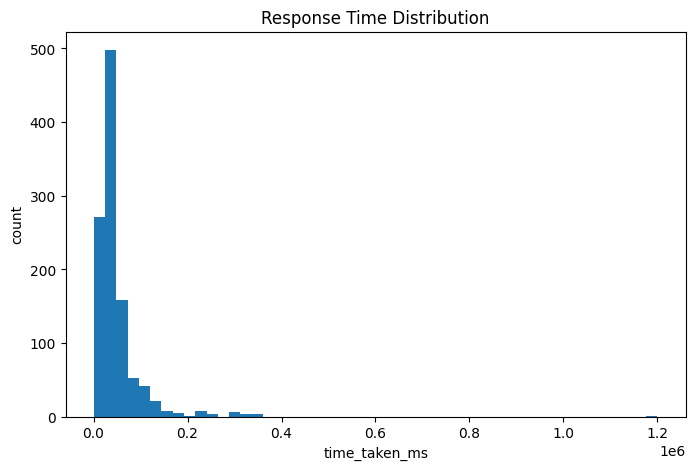

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["time_taken_ms"], bins=50)
plt.title("Response Time Distribution")
plt.xlabel("time_taken_ms")
plt.ylabel("count")
plt.show()

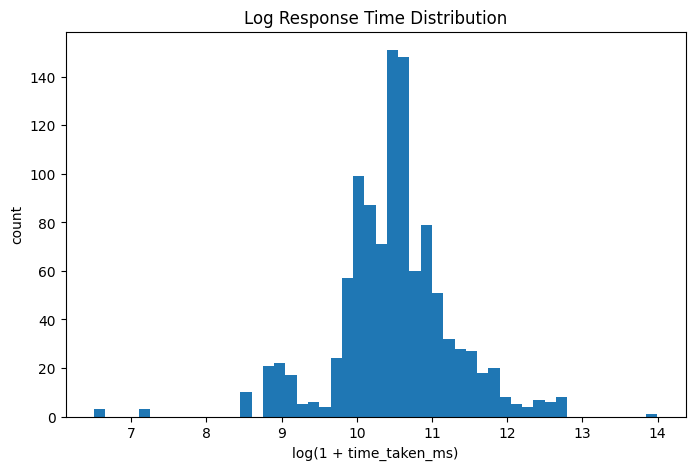

In [5]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["time_taken_ms"]), bins=50)
plt.title("Log Response Time Distribution")
plt.xlabel("log(1 + time_taken_ms)")
plt.ylabel("count")
plt.show()

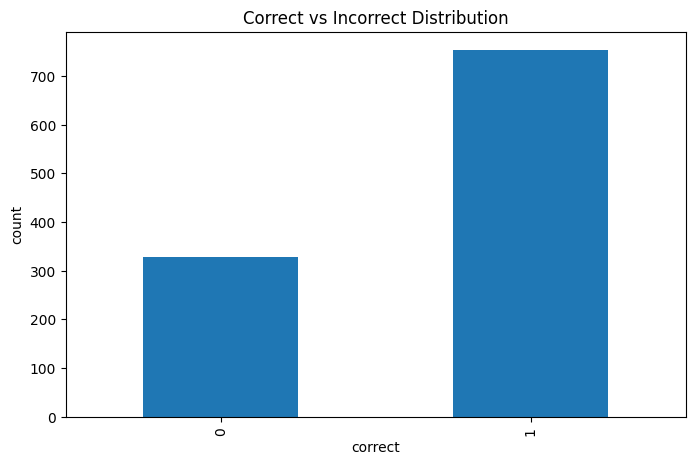

In [6]:
plt.figure(figsize=(8,5))
df["correct"].value_counts().sort_index().plot(kind="bar")
plt.title("Correct vs Incorrect Distribution")
plt.xlabel("correct")
plt.ylabel("count")
plt.show()

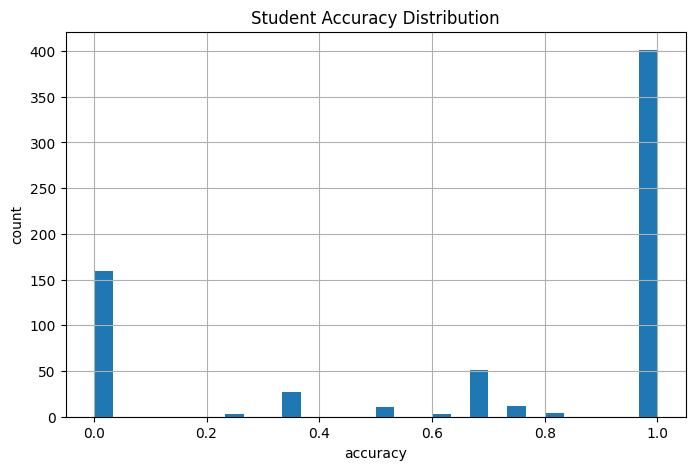

In [7]:
plt.figure(figsize=(8,5))
df.groupby("student_id")["correct"].mean().hist(bins=30)
plt.title("Student Accuracy Distribution")
plt.xlabel("accuracy")
plt.ylabel("count")
plt.show()

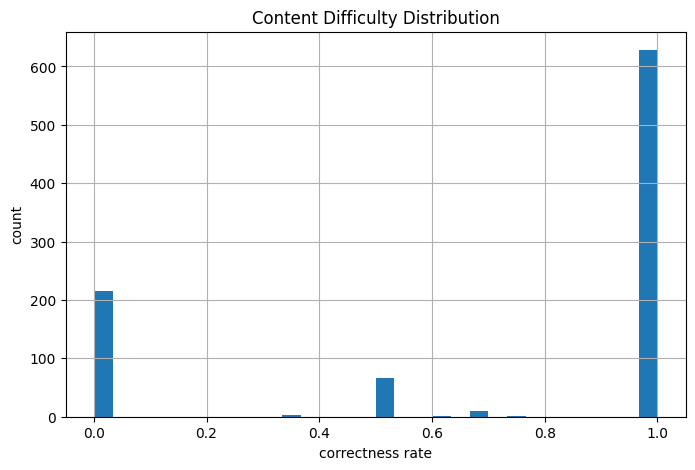

In [8]:
plt.figure(figsize=(8,5))
df.groupby("content_id")["correct"].mean().hist(bins=30)
plt.title("Content Difficulty Distribution")
plt.xlabel("correctness rate")
plt.ylabel("count")
plt.show()

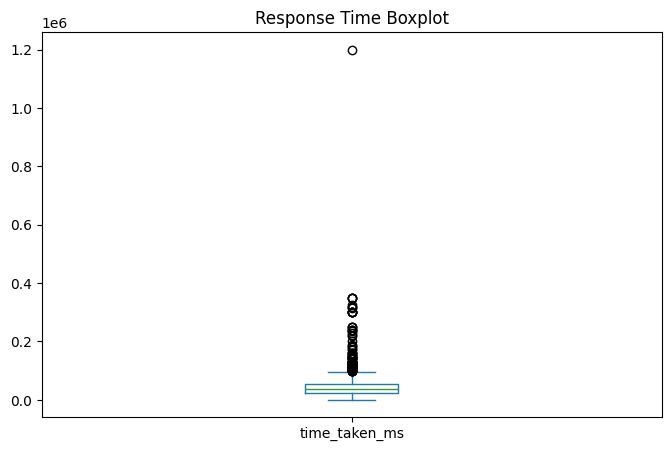

In [9]:
plt.figure(figsize=(8,5))
df["time_taken_ms"].plot(kind="box")
plt.title("Response Time Boxplot")
plt.show()

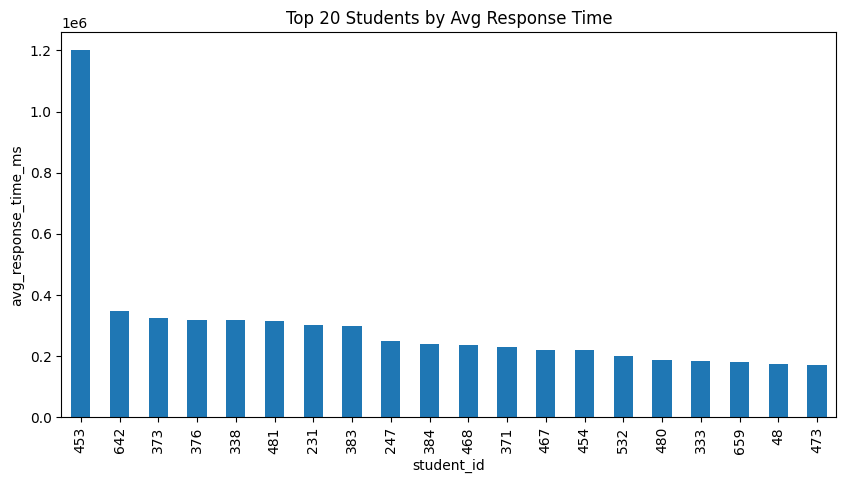

In [10]:
plt.figure(figsize=(10,5))
df.groupby("student_id")["time_taken_ms"].mean().sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Top 20 Students by Avg Response Time")
plt.xlabel("student_id")
plt.ylabel("avg_response_time_ms")
plt.show()

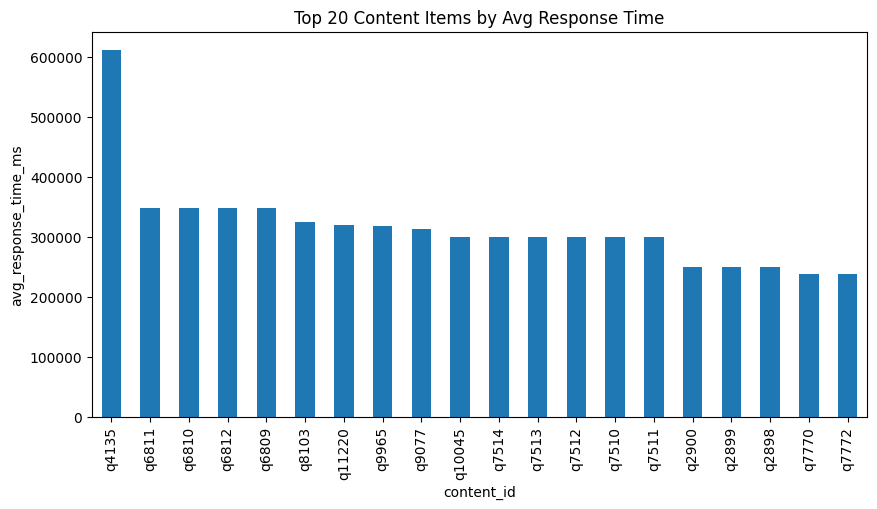

In [11]:
plt.figure(figsize=(10,5))
df.groupby("content_id")["time_taken_ms"].mean().sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Top 20 Content Items by Avg Response Time")
plt.xlabel("content_id")
plt.ylabel("avg_response_time_ms")
plt.show()

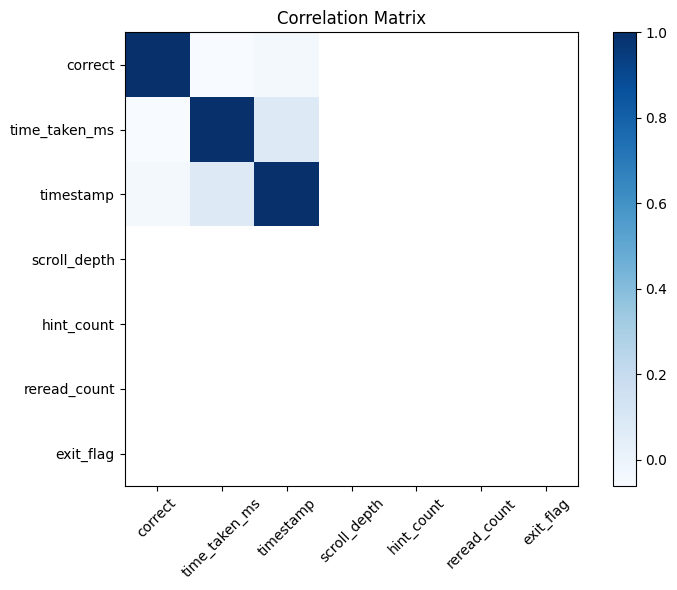

In [12]:
numeric_cols = ["correct", "time_taken_ms", "timestamp", "scroll_depth", "hint_count", "reread_count", "exit_flag"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
p99 = df["time_taken_ms"].quantile(0.99)
outliers = df[df["time_taken_ms"] > p99]

print("99th percentile:", p99)
print("Outlier rows:", len(outliers))
outliers.head()

99th percentile: 299600.0
Outlier rows: 10


,student_id,content_id,correct,time_taken_ms,timestamp,scroll_depth,hint_count,reread_count,exit_flag
257,231,q10045,1,300000,1567156993340,100,0,0,0
469,338,q9965,1,318000,1568706941883,100,0,0,0
546,373,q8103,1,324000,1568817001849,100,0,0,0
549,376,q11220,1,319000,1568819606292,100,0,0,0
714,453,q4135,0,1200000,1569368176508,100,0,0,0


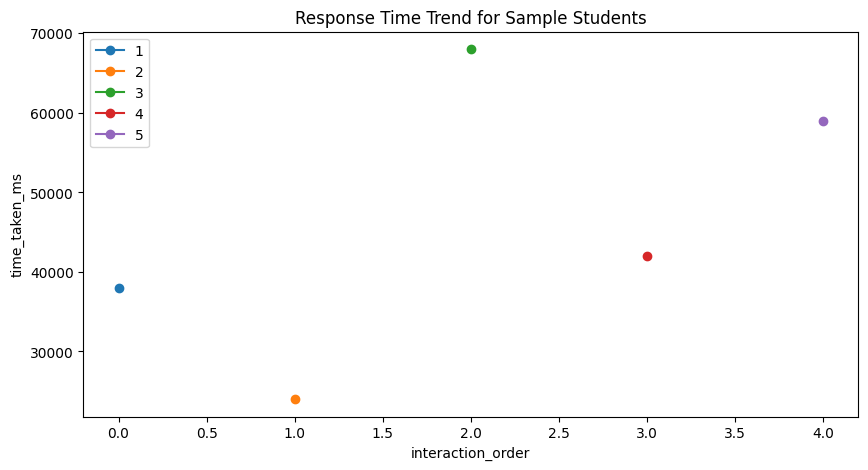

In [14]:
sample_students = df["student_id"].astype(str).unique()[:5]
sample_df = df[df["student_id"].astype(str).isin(sample_students)].copy()
sample_df["row_order"] = np.arange(len(sample_df))

plt.figure(figsize=(10,5))
for sid, grp in sample_df.groupby("student_id"):
    plt.plot(grp["row_order"], grp["time_taken_ms"], marker="o", label=str(sid))
plt.title("Response Time Trend for Sample Students")
plt.xlabel("interaction_order")
plt.ylabel("time_taken_ms")
plt.legend()
plt.show()